# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from statsmodels.stats.proportion import proportions_ztest

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head()

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**: 
- `El dataset no tiene valores ausentes. Y no cuenta con errores de que afecten el análisis del experimento.`

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
df['user_id'].nunique()

40000

 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df['gasto'].describe().round(2)

count    40000.00
mean         9.33
std         25.67
min          0.00
25%          0.00
50%          0.00
75%          0.00
max        303.68
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
df[df['converted'] == 1].describe().round(2)

,converted,gasto
count,5706.0,5706.00
mean,1.0,65.37
std,0.0,30.90
min,1.0,12.12
25%,1.0,42.95
50%,1.0,59.86
75%,1.0,80.37
max,1.0,303.68


 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
for col in ['landing','region','traffic_source','user_type']:
    proporciones = df[col].value_counts()
    print("\nConteo de categorías:")
    print(proporciones)



Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64

Conteo de categorías:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Conteo de categorías:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Conteo de categorías:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


In [11]:
for col in ['landing','region','traffic_source','user_type']:
    proporciones = (df[col].value_counts(normalize=True)*100).round(2)
    print("\nConteo de categorías:")
    print(proporciones)


Conteo de categorías:
B    50.04
A    49.96
Name: landing, dtype: float64

Conteo de categorías:
Norte        27.92
Centro       24.03
Sur          20.10
Occidente    16.00
Oriente      11.96
Name: region, dtype: float64

Conteo de categorías:
Organic     44.97
Ads         29.84
Email       15.31
Referral     9.89
Name: traffic_source, dtype: float64

Conteo de categorías:
Nuevo         65.08
Recurrente    34.92
Name: user_type, dtype: float64


✍️ **Comentario**: 

- `Todas las columnas tienen valores esperados. No hay valores erroneos, ni con errores de escritura.` 


## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [13]:
stat, p_value = stats.levene(gasto_A, gasto_B)
print(f"Estadístico de Levene: {stat}, P-value: {p_value}")

Estadístico de Levene: 29.17646453202917, P-value: 6.875301988016449e-08


In [14]:
#Gasto promedio de ambas páginas
print("Gasto promedio página A")
print(gasto_A.mean().round(2))
print()
print("Gasto promedio página B")
print(gasto_B.mean().round(2))

Gasto promedio página A
61.09

Gasto promedio página B
68.75


### Prueba: T de Student

**Hipótesis:** ¿En cuál de las dos páginas gastan más los usuarios?
- **Hipótesis nula (H₀):** El gasto promedio de usuarios convertidos en la página A es igual al gasto promedio de usuarios convertidos en la página B.
- **Hipótesis alternativa (H₁):** El gasto promedio de usuarios convertidos en la pagina A es diferente al gasto promedio de usuarios convertidos en la página B.

In [15]:
stats.ttest_ind(gasto_A, gasto_B, equal_var=False)

Ttest_indResult(statistic=-9.48101092267275, pvalue=3.627602231521493e-21)

In [16]:
# Aplicar prueba
t_stat, p_value = stats.ttest_ind(gasto_A, gasto_B, equal_var=False)

# Visualizar resultados
print(f"Estadístico : {t_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21


In [17]:
alpha = 0.05 #valor de significancia
if p_value < alpha:
    print ("Rechazamos la hipótesis nula: el gasto promedio de usuarios convertidos es diferente en la página A y en la página B.")
else:
    print ("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia de gasto promedio de usuarios converidos en la página A y en la página B")


Rechazamos la hipótesis nula: el gasto promedio de usuarios convertidos es diferente en la página A y en la página B.


### 📝 Conclusión e interpretación

**Decisión:**  
(Se rechaza la hipótesis nula)

**Interpretación de negocio:**  
Con base en una prueba T, tenemos evidencia suficiente para afirmar que hay una diferencia en el gasto promedio más alto convertido en la página B comparándolos con los usuarios de la página A. 

Los usuarios que gastaron en la página B, gastaron 68.75 en promedio; por otro lado, los usuarios que que gastaron en la página A, gastaron en promedio 61.09.

Este resultado se basa en una muestra de usuarios que realizaron una compra en alguna de las dos páginas. La acción a considerar sería implementar la página B.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z-Test

**Hipótesis:** ¿Cuál página es la que convierte más?
- **Hipótesis nula (H₀):** La tasa de conversión en la página A es igual al de la página B.
- **Hipótesis alternativa (H₁):** La tasa de conversión es diferente entre la página A y la página B.

In [18]:
# Número de usuarios convertidos por página
conversiones = df.groupby('landing')['converted'].sum()
conversiones
# Total de usuarios por página
totales = df.groupby('landing')['converted'].count()
totales
print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)

Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: converted, dtype: int64


In [19]:
exitos = [conversiones['A'], conversiones['B']]
exitos

[2512, 3194]

In [20]:
observaciones = [totales['A'], totales['B']]
observaciones

[19982, 20018]

In [21]:
# Aplicar prueba
z_stat, p_value = proportions_ztest (exitos, observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


In [22]:
alpha = 0.05 #valor de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: tenemos evidencia de conversión entre la página A y la página B")
else: 
    print("No rechazamos la hipótesis nula: no tenemos evidencia de conversión entre la página A y la página B")

Rechazamos la hipótesis nula: tenemos evidencia de conversión entre la página A y la página B


In [23]:
#Tasa de conversión para página A y página B
Tasa_A = conversiones['A'] / totales['A']
Tasa_B = conversiones['B'] / totales['B']
Diferencia = ((Tasa_B-Tasa_A)*100).round(2)
print("Diferencia tasa de conversión")
Diferencia

Diferencia tasa de conversión


3.38

### 📝 Conclusión e interpretación

**Decisión:**  
-`Se rechaza la hipótesis nula.`

**Interpretación de negocio:**  
El resultado es estadísticamente significativo (p < 0.05) en este caso, el valor p es muy chico y es menor al umbral, entonces tenemos evidencia suficiente para rechazar la hipótesis nula.

Esto nos confirma que la diferencia en la conversión no es casualidad y podemos informar al equipo que la página B es estadísticamente superior a la página A, con un 95% de confianza, y considerando que la tasa de conversión es de 3.38% mayor en la página B.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.


### Prueba Chi-Cuadrado (χ²)

**Hipótesis:** ¿La conversión depende de la fuente de tráfico?
- **Hipótesis nula (H₀):** La conversión es independiente de la fuente de tráfico.
- **Hipótesis alternativa (H₁):** La conversión depende de la fuente de tráfico.

In [24]:
# Conteo de valores
df['converted'].value_counts()

0    34294
1     5706
Name: converted, dtype: int64

In [25]:
df[['traffic_source','converted']].value_counts()

traffic_source  converted
Organic         0            15507
Ads             0            10176
Email           0             5205
Referral        0             3406
Organic         1             2480
Ads             1             1759
Email           1              918
Referral        1              549
dtype: int64

In [26]:
# Tabla de contingencia
tabla = pd.crosstab(df['traffic_source'], df['converted'])
tabla

converted,0,1
traffic_source,,
Ads,10176,1759
Email,5205,918
Organic,15507,2480
Referral,3406,549


In [27]:
tabla_pct = (pd.crosstab(df['traffic_source'], df['converted'], normalize='index')*100).round(2)
tabla_pct

converted,0,1
traffic_source,,
Ads,85.26,14.74
Email,85.01,14.99
Organic,86.21,13.79
Referral,86.12,13.88


In [28]:
# Aplicar prueba
chi2_contingency(tabla)


Chi2ContingencyResult(statistic=8.662108841397938, pvalue=0.0341375947833914, dof=3, expected_freq=array([[10232.47225,  1702.52775],
       [ 5249.55405,   873.44595],
       [15421.15445,  2565.84555],
       [ 3390.81925,   564.18075]]))

In [29]:
chi2_stat, p_value, dof, expected = chi2_contingency(tabla)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 8.662
Valor P: 0.034
Grados de libertad: 3

Frecuencias esperadas:
[[10232.47225  1702.52775]
 [ 5249.55405   873.44595]
 [15421.15445  2565.84555]
 [ 3390.81925   564.18075]]


In [30]:

alpha = 0.05 # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: La conversión depende de la fuente de tráfico")
else:
    print("No rechazamos la hipótesis nula: No tenemos evidencia suficiente de una asociación entre la fuente de tráfico y la conversión")



Rechazamos la hipótesis nula: La conversión depende de la fuente de tráfico


### 📝 Conclusión e interpretación

**Decisión:**  
`Rechazamos la hipótesis nula.`

**Interpretación de negocio:**  

Con base en un prueba de Chi Cuadrada de independencia, encontramos evidencia estadística de que la conversión está asociada a la fuente de tráfico.

En particular, los usuarios de la fuente de tráfico provenientes de Email muestran una mayor tasa de conversión con 14.99% que los usuarios provenientes de otras fuentes de tráfico. 

Los usuarios provenientes de Ads muestran una tasa de 14.74%, con solo una diferencia de 00.25%

Los usuarios provenientes de Referral con una tasa de 13.88%, con una diferencia de 1.11%.

Los usuarios provenientes de Organic con una tasa de 13.79%, con la mayor diferencia, de 1.2%.

Este resultado no implica causalidad directa ni evalúa si esta diferencia justifica decisiones diferenciadas desde una perspectiva de negocio. Las diferencias entre las tasas de conversión provenientes de las fuentes de tráfico no son tan distintas desde el punto de vista de relevancia práctica para el negocio. Por lo que un cambio radical en la estrategia de inversión de canales no es recomendable.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Prueba Chi-Cuadrado (χ²)



**Hipótesis:** ¿La conversión depende del tipo de usuario?
- **Hipótesis nula (H₀):** La conversión es independiente del tipo de usuario.
- **Hipótesis alternativa (H₁):** La conversión depende del tipo de usuario.



In [31]:
# Conteo de valores
df[['user_type','converted']].value_counts()

user_type   converted
Nuevo       0            22295
Recurrente  0            11999
Nuevo       1             3738
Recurrente  1             1968
dtype: int64

In [32]:
# Tabla de contingencia
tabla_user = pd.crosstab(df['user_type'], df['converted'])
tabla_user

converted,0,1
user_type,,
Nuevo,22295,3738
Recurrente,11999,1968


In [33]:
tabla_user_pct = (pd.crosstab(df['user_type'], df['converted'], normalize='index')*100).round(2)
tabla_user_pct

converted,0,1
user_type,,
Nuevo,85.64,14.36
Recurrente,85.91,14.09


In [34]:
# Aplicar prueba
chi2_contingency(tabla_user)


Chi2ContingencyResult(statistic=0.5134849494478645, pvalue=0.4736341272301974, dof=1, expected_freq=array([[22319.39255,  3713.60745],
       [11974.60745,  1992.39255]]))

In [35]:
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_user)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor P: {p_value:.3f}")
print(f"Grados de libertad: {dof}")
print("\nFrecuencias esperadas:")
print(expected)

Estadístico chi-cuadrado: 0.513
Valor P: 0.474
Grados de libertad: 1

Frecuencias esperadas:
[[22319.39255  3713.60745]
 [11974.60745  1992.39255]]


In [36]:
alpha = 0.05 # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: La conversión depende del tipo de usuario")
else:
    print("No rechazamos la hipótesis nula: la conversión no depende del tipo de usuario")

No rechazamos la hipótesis nula: la conversión no depende del tipo de usuario


### 📝 
Conclusión e interpretación

**Decisión:**  
`No rechazamos la hipótesis nula.`

**Interpretación de negocio:**  
Con base en un prueba de Chi Cuadrada de independencia, encontramos evidencia estadística de que la conversión está asociada al tipo de usuario.

En particular, los usuarios nuevos tienen una tasa de conversión de 14.36%, y los usuarios Recurrente tienen una tasa de conversión de 14.09%, la diferencia es de solo 0.27%, hay diferencia relevante entre ambas tasas.

Con este resultado tenemos evidencia suficiente de que la conversión no depende del tipo de usuario que interactúa. La recomendación sería mantener estrategias similares entre los tipos de usuarios.


## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

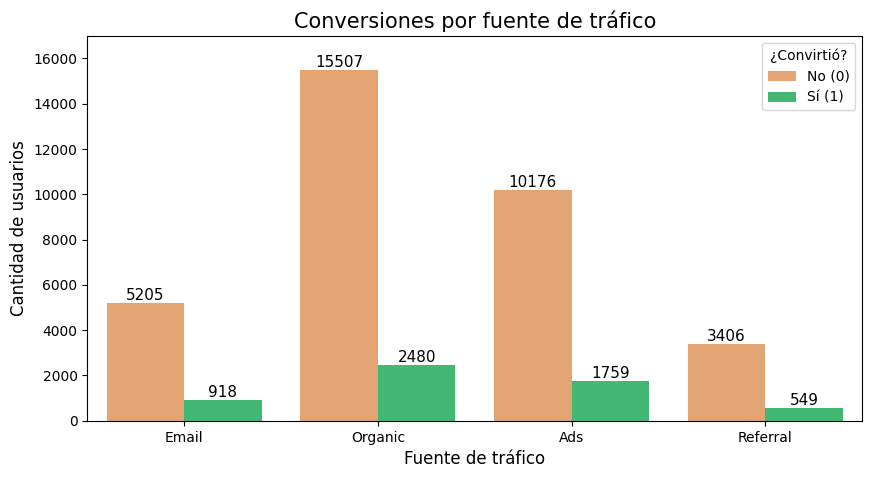

In [38]:
# Gráfico de barras agrupadas detallado
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='traffic_source', hue='converted', palette = ["#F4A261", "#2ECC71"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                      # Alinear centro del texto en coordenada
            va='bottom',                      # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente

# Detalles
plt.title('Conversiones por fuente de tráfico', fontsize=15)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,17000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ **Comentario**: 

`Gráfica de conversiones de usuario por fuente de tráfico.`

La fuente de tráfico con más conversiones por usuarios es Organic, con 2,480 usuarios. También tiene la mayor cantidad de usuarios que no convirtieron, con 15,507.
La fuente de tráfico Ads, tiene 1,759 conversiones por usuarios. Y tiene una cantidad de usuarios que no convirtieron de 10,176.  
La fuente de tráfico Email, tiene 918 conversiones por usuarios. Y tiene una cantidad de usuarios que no convirtieron de 5,205.
Referral es la fuente con menos conversiones por usuario, con 549 usuarios. Y también es la que tiene menor cantidad de usuarios que no convirtieron, con 3,406.
Se aprecia que a mayor cantidad de usuarios que convirtieron, la cantidad de usuarios que no convirtieron es proporcional en mayor escala.
Se recomienda hacer una revisión y comparación entre las fuente de tráfico Organic, porque tiene una cantidad muy alta de usuarios que no convierten; y Email, ya que Email tiene una tasa de conversión de 14.99%, y se podría revisar lo que está ayudando a que los usuarios conviertan para intentar aplicarlo a las otras fuentes.

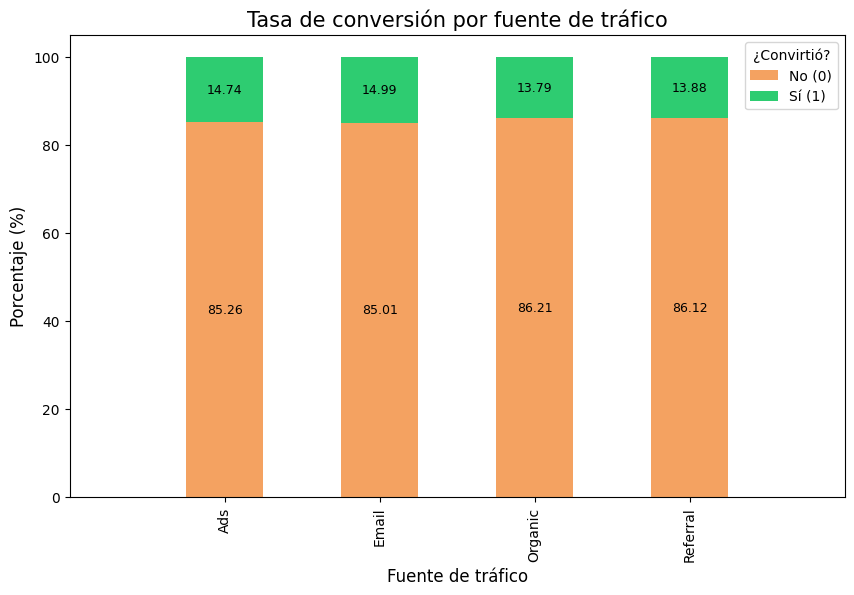

In [40]:
# Gráfica de barras apiladas detallada
ax = tabla_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#F4A261", "#2ECC71"])
# Agregar valores
for bar in ax.patches:                   # Recorrer todas las barras del gráfico
    height = bar.get_height()            # Obtener altura de barra (conteo de usuarios)
    ax.text(                             # Establecer coordenada X del texto (centro de la barra)
    bar.get_x() + bar.get_width() / 2,   # Establecer coordenada Y del texto
    bar.get_y() + height / 2,            # Valor a mostrar
    f'{height:.2f}',                     # Alinear centro del texto en coordenada
    ha='center', va='center',            # Alinear parte inferior del texto en coordenada
    fontsize=9, color='black')           # Tamaño de la fuente

plt.title('Tasa de conversión por fuente de tráfico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Fuente de tráfico', fontsize=12)
ax.set_xlim(-1, 4)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.show()


✍️ **Comentario**: 



`Gráfica tasa de conversión por fuente de tráfico.`

La fuente de tráfico con la mejor tasa de conversión por usuarios es Email con 14.99%, la fuente de tráfico con menor tasa de conversión por usuarios es Referral con 13.88%.
La fuente de tráfico que tiene la mayor tasa de conversión por usuarios que no convirtieron es Organic con 86.21%, la fuente de tráfico que tiene la menor tasa de conversión por usuarios que no convirtieron es Email con 85.01%.
Podemos concluir que aunque Organic tiene un mayor número de usuarios que las otras fuentes de tráfico con 15507 usuarios, también es la fuente de tráfico que tiene la mayor tasa de usuarios que no convirtieron con 86.21%. Por otro lado, Email es la fuente de tráfico que mejor tasa de conversión muestra con 14.99%. Por lo que la recomendación para el negocio es tener una inversión en atracción en Organic para mejorar la tasa de conversión, o invertir en atracción de usuarios por la fuente de tráfico de Email, ya que tiene la mejor tasa de conversión de las fuentes de tráfico.



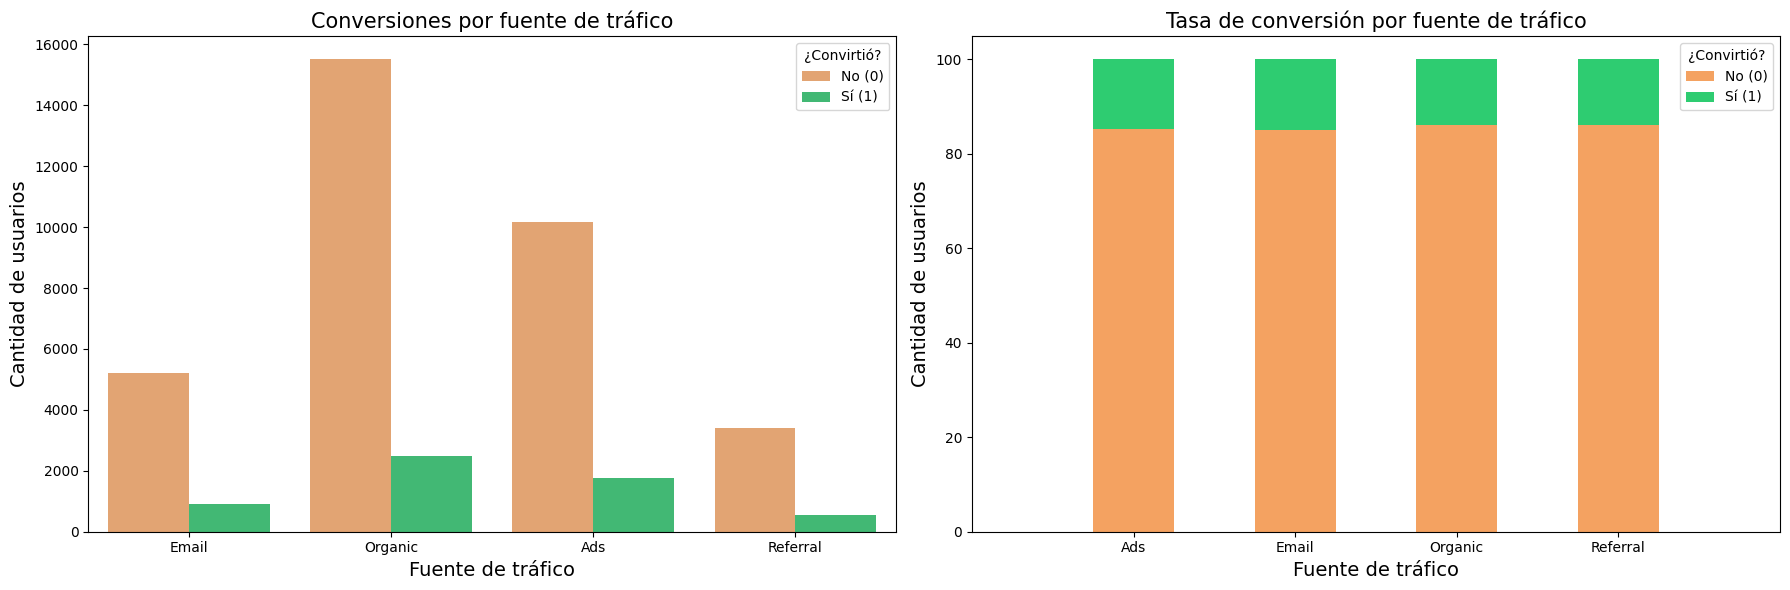

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barras agrupadas
# -----------------------------
sns.countplot(data=df, x='traffic_source', hue='converted', palette=["#F4A261", "#2ECC71"], ax=axes[0])

axes[0].set_title('Conversiones por fuente de tráfico', fontsize=15)
axes[0].set_xlabel('Fuente de tráfico', fontsize=14)
axes[0].set_ylabel('Cantidad de usuarios', fontsize=14)
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

# Barras apiladas
# -----------------------------
tabla_pct.plot(kind='bar', stacked=True, color=["#F4A261", "#2ECC71"], ax=axes[1])

axes[1].set_title('Tasa de conversión por fuente de tráfico', fontsize=15)
axes[1].set_xlabel('Fuente de tráfico', fontsize=14)
axes[1].set_ylabel('Cantidad de usuarios', fontsize=14)
axes[1].set_xlim(-1, 4)
axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Relación entre el tipo de usuario y la conversión

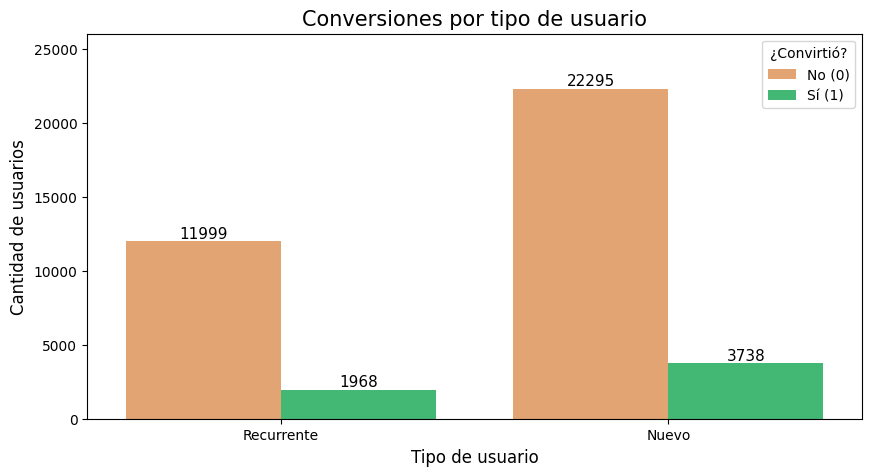

In [43]:
# Gráfico de barras agrupadas detallado
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x='user_type', hue='converted', palette = ["#F4A261", "#2ECC71"] )

# Agregar valores
for bar in ax.patches:        # Recorrer todas las barras del gráfico
    height = bar.get_height() # Obtener altura de barra (conteo de usuarios)
    ax.text(x=bar.get_x()+bar.get_width() /2, # Establecer coordenada X del texto (centro de la barra)
            y=height,                         # Establecer coordenada Y del texto
            s=height,                         # Valor a mostrar
            ha='center',                      # Alinear centro del texto en coordenada
            va='bottom',                      # Alinear parte inferior del texto en coordenada
            fontsize=11)                      # Tamaño de la fuente

# Detalles
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.ylim(0,26000)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

✍️ 
**Comentario**: 

Del total de usuarios Nuevos que son 26,033. Visualizamos que existen 3,738 que convirtieron, y hay 22,295 que no convirtieron.
Los usuarios tipo Recurrente tienen un total de 13,967 usuarios. Hay una cantidad de usuarios que convirtieron de 1,968. Y tenemos 11,999 usuarios que no convirtieron.
La prueba Chi-Cuadrada confirma con un valor_P de 0.474 que los resultados observados no son influidos por el tipo de usuario, hay suficiente evidencia para decir que no existe una diferencia significativa.
La recomendación sería enfocarse en mantener la misma estrategía entre los tipos de usuarios, y enfocarse en otra varibale como tipo de tráfico.


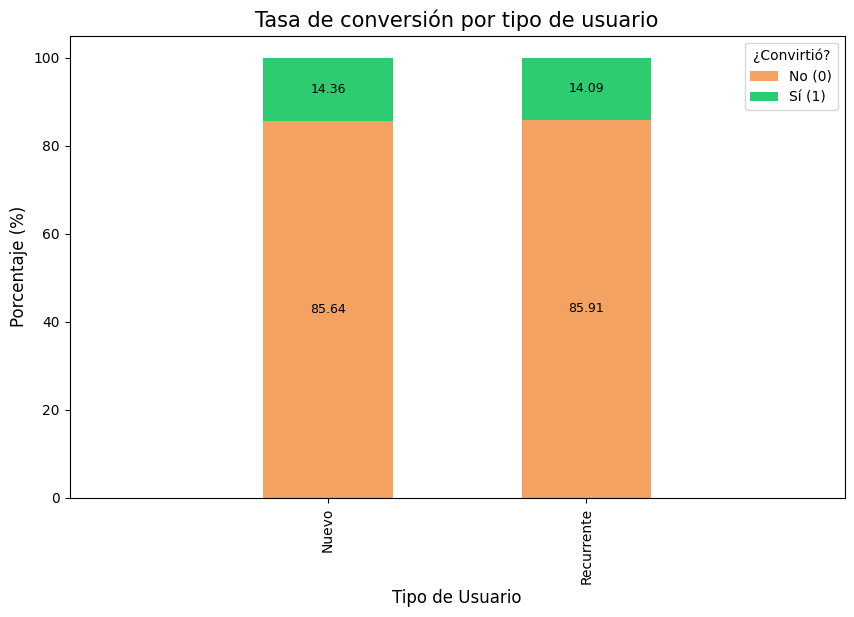

In [45]:
# Gráfica de barras apiladas detallada
ax = tabla_user_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#F4A261", "#2ECC71"])
# Agregar valores
for bar in ax.patches:                   # Recorrer todas las barras del gráfico
    height = bar.get_height()            # Obtener altura de barra (conteo de usuarios)
    ax.text(                             # Establecer coordenada X del texto (centro de la barra)
    bar.get_x() + bar.get_width() / 2,   # Establecer coordenada Y del texto
    bar.get_y() + height / 2,            # Valor a mostrar
    f'{height:.2f}',                     # Alinear centro del texto en coordenada
    ha='center', va='center',            # Alinear parte inferior del texto en coordenada
    fontsize=9, color='black')           # Tamaño de la fuente

plt.title('Tasa de conversión por tipo de usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de Usuario', fontsize=12)
ax.set_xlim(-1, 2)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
plt.show()

✍️ **Comentario**: 


Las tasas de conversión entre los tipos de usuarios no tienen diferencia significativa. Los usuarios Nuevos tienen una tasa de conversión de 14.36%, mientras que los usuarios Recurrente tienen una tasa de conversión de 14.09%. La diferencia es de solo 0.27% entre los dos tipos de usuarios.
Los usuarios Nuevos, tienen una tasa de usuarios que no convirtieron de 85.64%, y los usuarios Recurrente tienen una tasa de usuarios que no convirtieron de 85.91%.
Esto nos dice que el tipo de usuario no tiene impacto en la tasa de conversión de los usuarios.


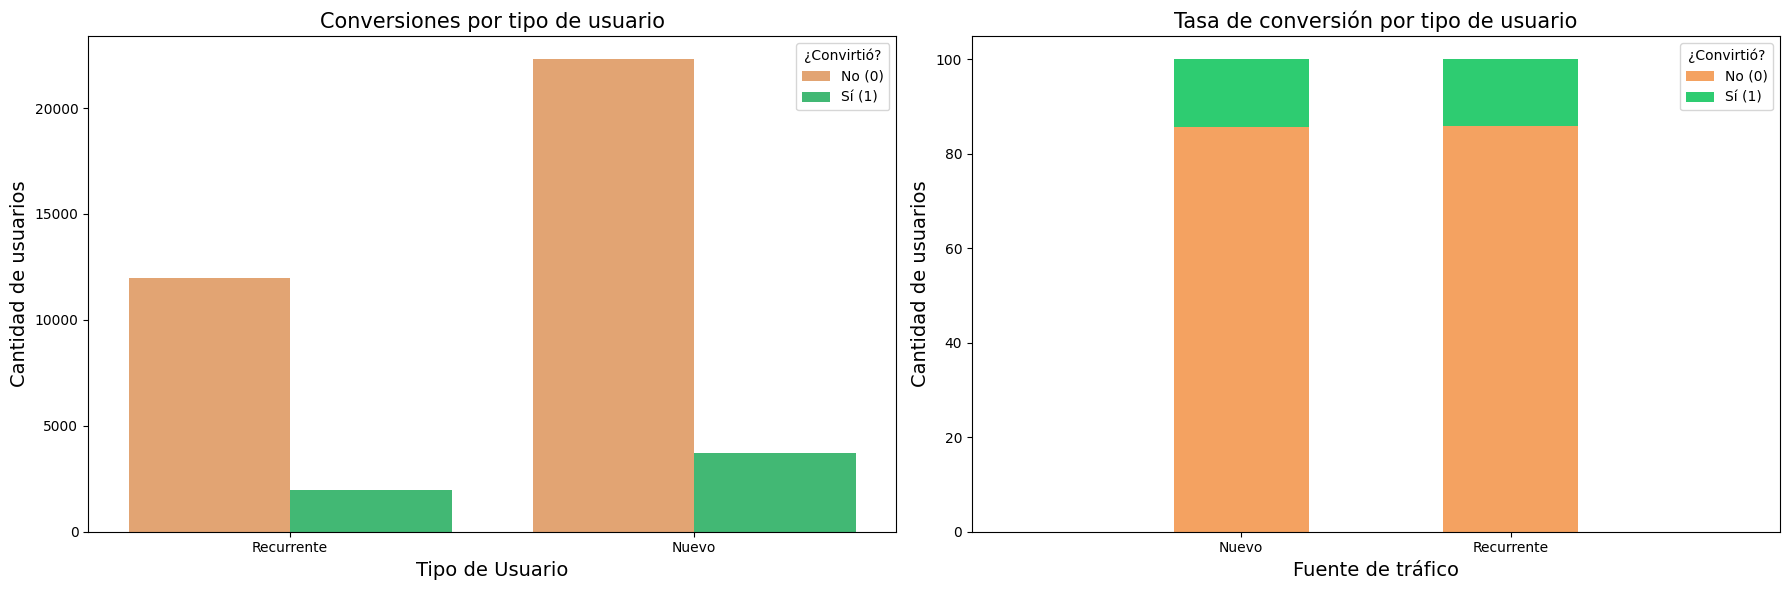

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barras agrupadas
# -----------------------------
sns.countplot(data=df, x='user_type', hue='converted', palette=["#F4A261", "#2ECC71"], ax=axes[0])

axes[0].set_title('Conversiones por tipo de usuario', fontsize=15)
axes[0].set_xlabel('Tipo de Usuario', fontsize=14)
axes[0].set_ylabel('Cantidad de usuarios', fontsize=14)
axes[0].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])

# Barras apiladas
# -----------------------------
tabla_user_pct.plot(kind='bar', stacked=True, color=["#F4A261", "#2ECC71"], ax=axes[1])

axes[1].set_title('Tasa de conversión por tipo de usuario', fontsize=15)
axes[1].set_xlabel('Fuente de tráfico', fontsize=14)
axes[1].set_ylabel('Cantidad de usuarios', fontsize=14)
axes[1].set_xlim(-1, 2)
axes[1].legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- Gasto promedio página A: `$61.09`
- Gasto promedio página B: `$68.75`
- Diferencia: `$7.66`
- Resultado de la prueba T: p-value= `1.06e-20`
- **Interpretación:**
- Con base en una prueba T, la cual arrojó un valor menor que el 0.05 (valor de significancia), con un resultado de 1.06e-20, rechazamos la hipótesis nula. Tenemos evidencia suficiente para afirmar que hay una diferencia en el gasto promedio, la página B tiene un gasto promedio mayor, con una diferencia de $7.66.

<br>

**Tasa de conversión:** 
- Tasa de conversión página A: `12.57%`
- Tasa de conversión página B: `15.95%`
- Diferencia: `3.38%`
- Resultado de la prueba Z: p-value= `3.76e-22`
- **Interpretación:**
- Con base en una prueba Z, la cual arrojó un valor menor que el 0.05 (valor de significancia), con un resultado de 3.76e-22, rechazamos la hipótesis nula. Tenemos evidencia suficiente para afirmar que hay una diferencia en la tasa de conversión entre ambas páginas, la página B tiene una tasa de conversión mayor, con una diferencia de 3.38%.

---

#### 📊 **Segmentación por fuente de tráfico**
- Resultado de la prueba Chi cuadrado: `8.662`
- P-value= `0.034`
- **Interpretación:**
- Rechazamos la hipótesis nula, se encontró evidencia estadística de acuerdo al resultado de la prueba Chi cuadrado con un valor-p de 0.034, quiere decir que la correlación entre ambos factores es existente. La conversión depende de la fuente de tráfico.
 
---

#### 📊 **Segmentación por tipo de usuario**

- Resultado de la prueba Chi cuadrado: `0.513`
- P-value= `0.474`
- **Interpretación:**
- No rechazamos la hipótesis nula, no tenemos evidencia suficiente de una asociación entre el tipo de usuario y la conversión, de acuerdo al resultado de la prueba Chi cuadrado con un valor-p de 0.474, no podemos descartar que la diferencia observada en las tasas de conversión entre tipos de usuario pudo ser producto del azar.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 
- Tomando en cuenta la correlación entre la fuente de tráfico y la conversión. Se recomienda hacer un análisis del desempeño de las tasas de conversión de acuerdo al número de usuarios que llegan desde esas fuentes, ya que se puede estar percibiendo mucho abandono que se puede convertir en conversión e ingreso para el negocio. A pesar de que se visualiza que no hay mucha diferencia entre las tasas de conversión en la gráfica de tasa de conversión, podemos ver que hay fuentes que tienen un tráfico importante, pero tienen un número importante de usuarios que no convirtieron, como Organic con una tasa de conversión de 13.79%, si lo comparamos con Email con 14.99%, que aunque no tiene el mismo tráfico de usuarios, tiene una mejor tasa de conversión que Organic. 
- Después de analizar la interacción de la conversión por los tipos de usuarios. Tenemos como resultado un Chi-cuadrado de 0.513, es un valor bajo, lo que indica poca diferencia entre los grupos. El P-value es de 0.474, que nos indica que no hay suficiente evidencia estadística para rechazar la hipótesis nula. Los resultados podrían deberse al azar.
La recomendación es no realizar una estrategia distintiva entre los tipos de clientes, y enfocar la estrategía en otra variable como la fuente de tráfico.
